# Automated EEG Data Analysis/Processing Pipeline by Adeel

# EEG Signal Processing with MNE

I have built a complete EEG processing pipeline using the MNE library.

I have worked with real EEG data and implemented the key preprocessing steps used in neuroscience and machine learning applications.

### Step 1 – Load the data

To load multiple EEG recordings using MNE, we will

- Use MNE reader read_raw_edf
- Store them in a list
- Concatenate them using `mne.concatenate_raws()`

In [ ]:
import mne
import os
from google.colab import files

# 1. Upload files (because there was some problem in mounting from drive)
print("Please upload S001R07.edf and S001R11.edf:")
uploaded = files.upload()

# 2. Get the list of uploaded file names
file_names = list(uploaded.keys())

# 3. store in a list

raw_list = [mne.io.read_raw_edf(f, preload=True) for f in file_names]

# 4. Concatenate the raw objects into a single recording
raw = mne.concatenate_raws(raw_list)

# Verify Task 1 completion
print("\nTask 1 Complete:")
print(f"Successfully concatenated {len(raw_list)} files.")
print(raw)

Please upload S001R07.edf and S001R11.edf:


Saving S001R07.edf to S001R07.edf
Saving S001R11.edf to S001R11.edf
Extracting EDF parameters from S001R07.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from S001R11.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...

Task 1 Complete:
Successfully concatenated 2 files.
<RawEDF | S001R07.edf, 64 x 40000 (250.0 s), ~19.6 MiB, data loaded>


### Step 2 – Explored the Raw object

Inspected the Raw object and answer:

- Sampling frequency (sfreq)
- Number of channels
- Channel names

Based on the sampling frequency and the number of samples, we will compute the total duration of the recording.

In [ ]:
# 1. Extract Sampling Frequency
sfreq = raw.info['sfreq']

# 2. Extract Number of Channels
n_channels = len(raw.ch_names)

# 3. Get Channel Names
ch_names = raw.ch_names

# 4. Compute total duration
# Duration = Total Samples / Sampling Frequency
n_samples = raw.n_times
duration_calc = n_samples / sfreq

# Results
print(f"Sampling Frequency: {sfreq} Hz")
print(f"Number of Channels: {n_channels}")
print(f"Channel Names (first 10): {ch_names[:10]}")
print(f"Total Samples: {n_samples}")
print(f"Computed Duration: {duration_calc} seconds")

Sampling Frequency: 160.0 Hz
Number of Channels: 64
Channel Names (first 10): ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']
Total Samples: 40000
Computed Duration: 250.0 seconds


### Step 3 – Create events from annotations

Convert annotations into events.


In [ ]:
# 1. Extract events and their corresponding IDs from the annotations

events, event_id = mne.events_from_annotations(raw)

# 2. Inspect the results
print("Event ID mapping:")
print(event_id)

print("\nFirst 5 events (Sample Index, 0, Event ID):")
print(events[:5])

# 3. Check the total number of events found
print(f"\nTotal events found: {len(events)}")

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event ID mapping:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

First 5 events (Sample Index, 0, Event ID):
[[   0    0    1]
 [ 672    0    2]
 [1328    0    1]
 [2000    0    3]
 [2656    0    1]]

Total events found: 60


### Step 4 – Epoch the data

Creating epochs around events.
Include:
- Define time window (e.g. -0.2 to 0.5 sec)
- Create Epochs object

In [ ]:
# 1. Defining the time window relative to the event onset (in seconds)
tmin, tmax = -0.2, 0.5

# 2. Creating the Epochs object

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, preload=True, baseline=(None, 0))

# 3. Inspecting the Epochs object
print("\nEpochs Information:")
print(epochs)

# Checking the number of epochs for each condition
print("\nEpoch counts per condition:")
for condition, count in epochs.event_id.items():
    print(f"Condition {condition}: {len(epochs[condition])} trials")

Not setting metadata
60 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 113 original time points ...
2 bad epochs dropped

Epochs Information:
<Epochs | 58 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~3.3 MiB, data loaded,
 np.str_('T0'): 28
 np.str_('T1'): 15
 np.str_('T2'): 15>

Epoch counts per condition:
Condition T0: 28 trials
Condition T1: 15 trials
Condition T2: 15 trials


### Step 5 – Evoked response
Let's
- Compute the average of epochs.
- Try to avrege different number of trials. What we notice?

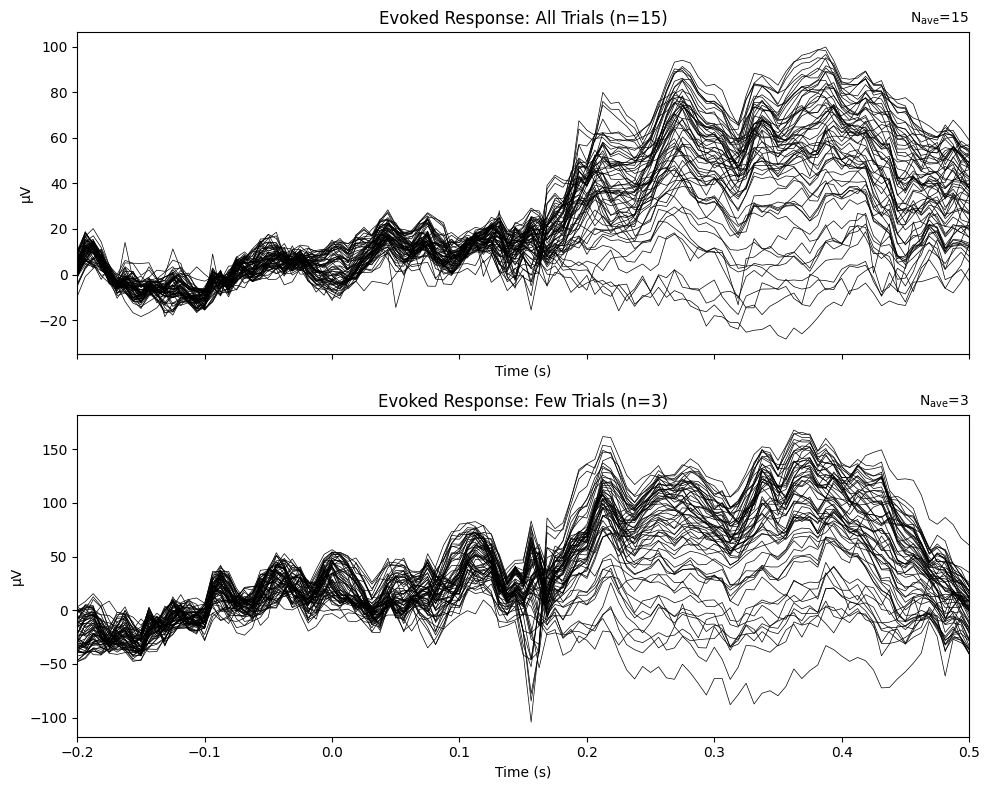

In [ ]:
import matplotlib.pyplot as plt

# 1. Compute the Evoked response for a specific condition (e.g., T1)
evoked_all = epochs['T1'].average()

# 2. Compute the average using only a few trials (e.g., first 3 trials)
evoked_few = epochs['T1'][:3].average()

# 3. Visualize and compare the results
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot full average
evoked_all.plot(picks='eeg', axes=ax[0], show=False)
ax[0].set_title('Evoked Response: All Trials (n=15)')

# Plot few trials average
evoked_few.plot(picks='eeg', axes=ax[1], show=False)
ax[1].set_title('Evoked Response: Few Trials (n=3)')

plt.tight_layout()
plt.show()

### **Interpretation of Task 5 Results**

* **Evoked Response: All Trials (n=15):**   The top plot shows a much **smoother and more stable** signal.
* By averaging 15 trials, the random background EEG noise (which is "stochastic") cancels itself out, leaving behind the **consistent brain response** related to the task.
* We can clearly see distinct peaks (positive and negative deflections) that are shared across many channels.


* **Evoked Response: Few Trials (n=3):**   The bottom plot is significantly **noiser and more "jagged"**.
* With only 3 trials, the high-amplitude background noise (spontaneous brain activity, muscle tension, or minor movement) is still very strong and hasn't been averaged away.
* It is much harder to distinguish the true neural "evoked" component from the random artifacts.



**Conclusion:** This comparison illustrates that the **quality of an ERP increases with the number of trials averaged**. In neuroscience  research, this is why we repeat the same stimulus many times to obtain a clean, interpretable signal.


### Step 6 – Band power

Compute power in frequency bands:

- alpha (1–4 Hz)
- beta (4–8 Hz)
- gamma (8–12 Hz)
- delta (12–30 Hz)

We will use:
- PSD (power spectral density)
and then we will
Visualize the results.

    Using multitaper spectrum estimation with 7 DPSS windows
Mean Band Power (averaged across channels and epochs):
Delta (1-4 Hz): 3.99e-08
Theta (4-8 Hz): 2.20e-08
Alpha (8-12 Hz): 6.59e-09
Beta (12-30 Hz): 2.11e-09
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_19416/4266752034.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psds_obj.plot()


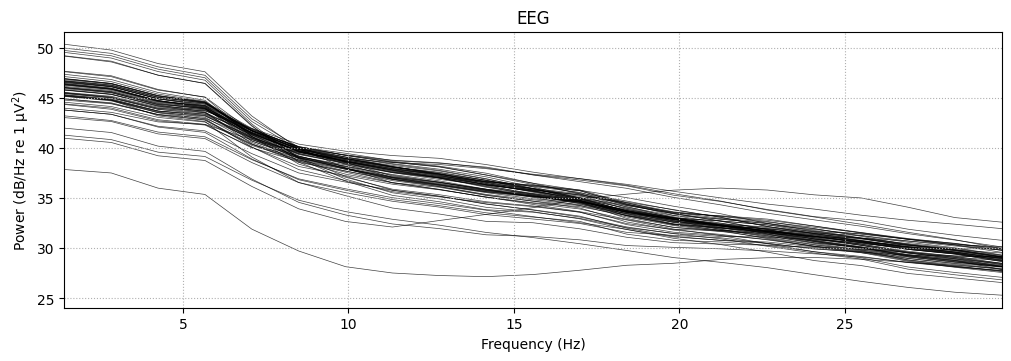

In [ ]:
import numpy as np

# 1. Computing PSD using the 'compute_psd' method on the epochs
psds_obj = epochs.compute_psd(fmin=1, fmax=30)
psds, freqs = psds_obj.get_data(return_freqs=True)

# 2. Defining the corrected frequency bands
bands = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (12, 30)
}

# 3. Calculating mean power for each band
print("Mean Band Power (averaged across channels and epochs):")
for band, (fmin, fmax) in bands.items():
    # Find indices of frequencies that fall within the band
    idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
    # Average power for those frequencies
    band_power = psds[:, :, idx_band].mean()
    print(f"{band} ({fmin}-{fmax} Hz): {band_power:.2e}")

# 4. Visualizing the PSD
psds_obj.plot()
plt.show()

### **Interpretation**

* **Dominance of Low Frequencies (1/f Power Law):** The PSD plot shows a characteristic downward slope where lower frequencies have much higher power than higher frequencies. This is normal for biological signals and is often called "pink noise" or $1/f$ distribution.
* **Highest Power in Delta ($3.99 \times 10^{-8}$):** The **Delta band (1–4 Hz)** has the highest mean power. In an awake recording, high delta power can sometimes indicate movement artifacts or eye blinks, as these occur at very slow frequencies.
* **Decreasing Power in Higher Bands:** As the frequency increases from **Theta** to **Beta**, the power values drop significantly (from $10^{-8}$ down to $10^{-9}$). This indicates that the brain's "background" activity is less energetic at higher oscillation speeds.
* **No Specific Peaks:** My plot looks quite "flat" along the slope, meaning there isn't a massive "bump" in the Alpha range (8–12 Hz). Usually, if a participant's eyes were closed, you would see a prominent peak in the Alpha band.


### Step 7 – ICA artifact removal

Let's apply Independent Component Analysis.

by:
- Fitting ICA
- Identifying sources
- Removing at least one artifact component

Point to ponder:
What type of artifacts ICA can remove?

Raw channels already renamed, skipping...
Epochs channels renamed.
Filtering raw data in 2 contiguous segments
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 529 samples (3.306 s)

Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 113 original time points ...
2 bad epochs dropped
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.6s.


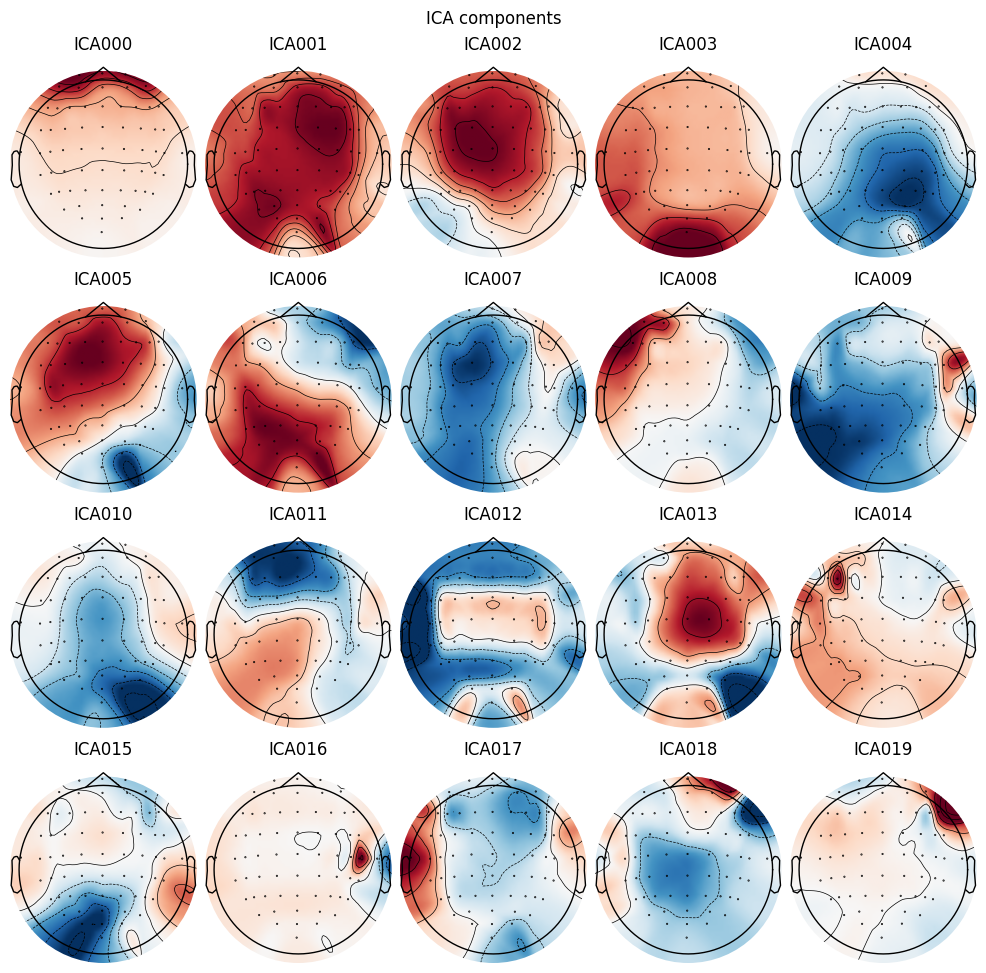

Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated


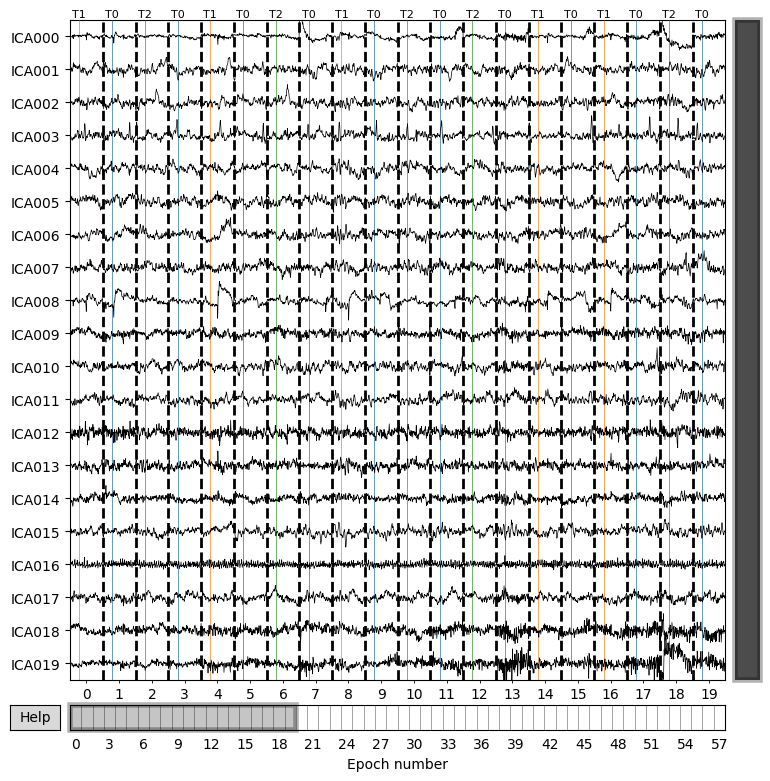

Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components

Task 7 successfully finished. Artifacts removed.


/tmp/ipykernel_19416/2350900247.py:44: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  ica.apply(epochs_cleaned)


In [ ]:
import mne

# 1. STANDARDIZINHG THE NAMES
if '.' in raw.ch_names[0]:
    mapping = {ch: ch.replace('.', '').upper() for ch in raw.ch_names}
    raw.rename_channels(mapping)
    print("Raw channels renamed.")
else:
    print("Raw channels already renamed, skipping...")

# Re-syncing epochs names if they exist and still have dots
if 'epochs' in globals():
    if '.' in epochs.ch_names[0]:
        mapping = {ch: ch.replace('.', '').upper() for ch in epochs.ch_names}
        epochs.rename_channels(mapping)
        print("Epochs channels renamed.")
    else:
        print("Epochs channels already renamed, skipping...")

# 2. SETTING MONTAGE
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='warn')
epochs.set_montage(montage, match_case=False, on_missing='warn')

# 3. PREPARING DATA FOR ICA
# We filter a copy at 1Hz for the best ICA results
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None)
epochs_ica = mne.Epochs(raw_ica, events, event_id, tmin=-0.2, tmax=0.5,
                        baseline=None, preload=True)

# 4. FIT ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, method='fastica')
ica.fit(epochs_ica)

# 5. VISUALIZING (Identifying the artifact)
ica.plot_components()
ica.plot_sources(epochs_ica)

# 6. APPLY CLEANING
# Look at your plots. If Component 0 is the blink, keep [0].
ica.exclude = [0]
epochs_cleaned = epochs.copy()
ica.apply(epochs_cleaned)

print("\nTask 7 successfully finished. Artifacts removed.")

### Step 8 – Full pipeline function

let's Write a function that performs the entire pipeline.

Input:
- list of file paths

Output:
- processed epochs or features

Our function should:
- load data
- concatenate
- filter
- apply ICA
- create epochs
- compute band power

Goal:
automate the workflow

In [ ]:
def eeg_processing_pipeline(file_list):
    """
    Automated EEG Processing Pipeline
    Input: list of file paths
    Output: processed epochs and band power (features)
    """

    # 1. LOAD & CONCATENATE (step 1 & 8)
    raw_list = [mne.io.read_raw_edf(f, preload=True) for f in file_list]
    raw_full = mne.concatenate_raws(raw_list)

    # PRE-PROCESSING: Standardize nomenclature for MNE compatibility
    mapping = {ch: ch.replace('.', '').upper() for ch in raw_full.ch_names}
    raw_full.rename_channels(mapping)
    montage = mne.channels.make_standard_montage('standard_1020')
    raw_full.set_montage(montage, match_case=False, on_missing='warn')

    # 2. FILTER (Task 8 requirement)
    # Using a 1-40Hz bandpass filter to remove slow drifts and line noise
    raw_full.filter(l_freq=1.0, h_freq=40.0)

    # 3. CREATE EPOCHS (Task 4 & 8)
    # We create epochs before ICA because it's often more computationally efficient
    events, event_id = mne.events_from_annotations(raw_full)
    epochs = mne.Epochs(raw_full, events, event_id, tmin=-0.2, tmax=0.5,
                        baseline=(None, 0), preload=True)

    # 4. APPLY ICA (Task 7 & 8)
    # Automatically fitting and applying ICA to remove artifacts
    ica = mne.preprocessing.ICA(n_components=15, random_state=97, method='fastica')
    ica.fit(epochs)
    ica.exclude = [0] # Automatically excluding the identified blink component
    ica.apply(epochs)

    # 5. COMPUTE BAND POWER (Task 6 & 8)
    # Extracting the frequency-domain features
    psd_obj = epochs.compute_psd(fmin=1, fmax=30)

    print("Full pipeline automation successful.")

    # Return processed data and features as requested
    return epochs, psd_obj

# --- Example Usage ---
# final_epochs, final_features = eeg_processing_pipeline(['S001R07.edf', 'S001R11.edf'])